# Apollo Phase 0 — Dataset Audit

Analyze MAESTRO v3 to understand what we're working with:
- File count, total duration
- Velocity distribution (how expressive is the data?)
- Note density / timing characteristics
- Pedal usage patterns
- Pitch range coverage

In [1]:
import pretty_midi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import json

sns.set_theme(style='whitegrid')
DATA_DIR = Path.home() / 'Projects' / 'apollo' / 'data' / 'raw' / 'maestro-v3.0.0'

In [2]:
# Load metadata
meta = pd.read_csv(DATA_DIR / 'maestro-v3.0.0.csv')
print(f'Total pieces: {len(meta)}')
print(f'Splits: {meta["split"].value_counts().to_dict()}')
print(f'Total duration: {meta["duration"].sum() / 3600:.1f} hours')
print(f'Unique composers: {meta["canonical_composer"].nunique()}')
print(f'\nDuration stats (seconds):')
meta['duration'].describe()

Total pieces: 1276
Splits: {'train': 962, 'test': 177, 'validation': 137}
Total duration: 198.7 hours
Unique composers: 60

Duration stats (seconds):


count    1276.000000
mean      560.463595
std       443.057431
min        45.155208
25%       261.981576
50%       429.168241
75%       685.018817
max      2624.663508
Name: duration, dtype: float64

In [3]:
# Analyze a sample of MIDI files for velocity, note density, pitch range, pedal
np.random.seed(42)
sample_indices = np.random.choice(len(meta), size=min(200, len(meta)), replace=False)
sample_meta = meta.iloc[sample_indices]

all_velocities = []
all_pitches = []
all_durations = []
all_ioi = []  # inter-onset intervals
note_counts = []
pedal_usage = []  # fraction of time sustain pedal is active
file_stats = []

for _, row in tqdm(sample_meta.iterrows(), total=len(sample_meta), desc='Analyzing MIDI files'):
    midi_path = DATA_DIR / row['midi_filename']
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
    except Exception as e:
        print(f'Error loading {midi_path}: {e}')
        continue
    
    for inst in pm.instruments:
        if inst.is_drum:
            continue
        notes = inst.notes
        if len(notes) == 0:
            continue
        
        velocities = [n.velocity for n in notes]
        pitches = [n.pitch for n in notes]
        durs = [n.end - n.start for n in notes]
        onsets = sorted([n.start for n in notes])
        ioi = np.diff(onsets)
        
        all_velocities.extend(velocities)
        all_pitches.extend(pitches)
        all_durations.extend(durs)
        all_ioi.extend(ioi[ioi > 0])  # skip simultaneous notes
        note_counts.append(len(notes))
        
        # Pedal analysis (CC 64 = sustain)
        pedal_events = [cc for cc in inst.control_changes if cc.number == 64]
        if pedal_events and pm.get_end_time() > 0:
            pedal_on_time = 0
            last_on = None
            for cc in sorted(pedal_events, key=lambda x: x.time):
                if cc.value >= 64 and last_on is None:
                    last_on = cc.time
                elif cc.value < 64 and last_on is not None:
                    pedal_on_time += cc.time - last_on
                    last_on = None
            pedal_usage.append(pedal_on_time / pm.get_end_time())
        
        file_stats.append({
            'filename': row['midi_filename'],
            'n_notes': len(notes),
            'duration': row['duration'],
            'notes_per_sec': len(notes) / max(row['duration'], 0.1),
            'mean_velocity': np.mean(velocities),
            'std_velocity': np.std(velocities),
            'velocity_range': max(velocities) - min(velocities),
            'pitch_range': max(pitches) - min(pitches),
            'mean_pitch': np.mean(pitches),
        })

stats_df = pd.DataFrame(file_stats)
print(f'\nAnalyzed {len(stats_df)} files successfully')
print(f'Total notes in sample: {len(all_velocities):,}')

Analyzing MIDI files:   0%|          | 0/200 [00:00<?, ?it/s]

Analyzing MIDI files:   2%|▏         | 3/200 [00:00<00:06, 28.35it/s]

Analyzing MIDI files:   3%|▎         | 6/200 [00:00<00:16, 11.72it/s]

Analyzing MIDI files:   4%|▍         | 9/200 [00:00<00:11, 16.17it/s]

Analyzing MIDI files:   6%|▌         | 12/200 [00:00<00:13, 14.08it/s]

...

Analyzing MIDI files:  98%|█████████▊| 195/200 [00:18<00:00,  8.44it/s]

Analyzing MIDI files:  98%|█████████▊| 197/200 [00:19<00:00,  8.49it/s]

Analyzing MIDI files: 100%|██████████| 200/200 [00:19<00:00, 10.46it/s]

Analyzing MIDI files: 100%|██████████| 200/200 [00:19<00:00, 10.43it/s]


Analyzed 200 files successfully
Total notes in sample: 1,023,137


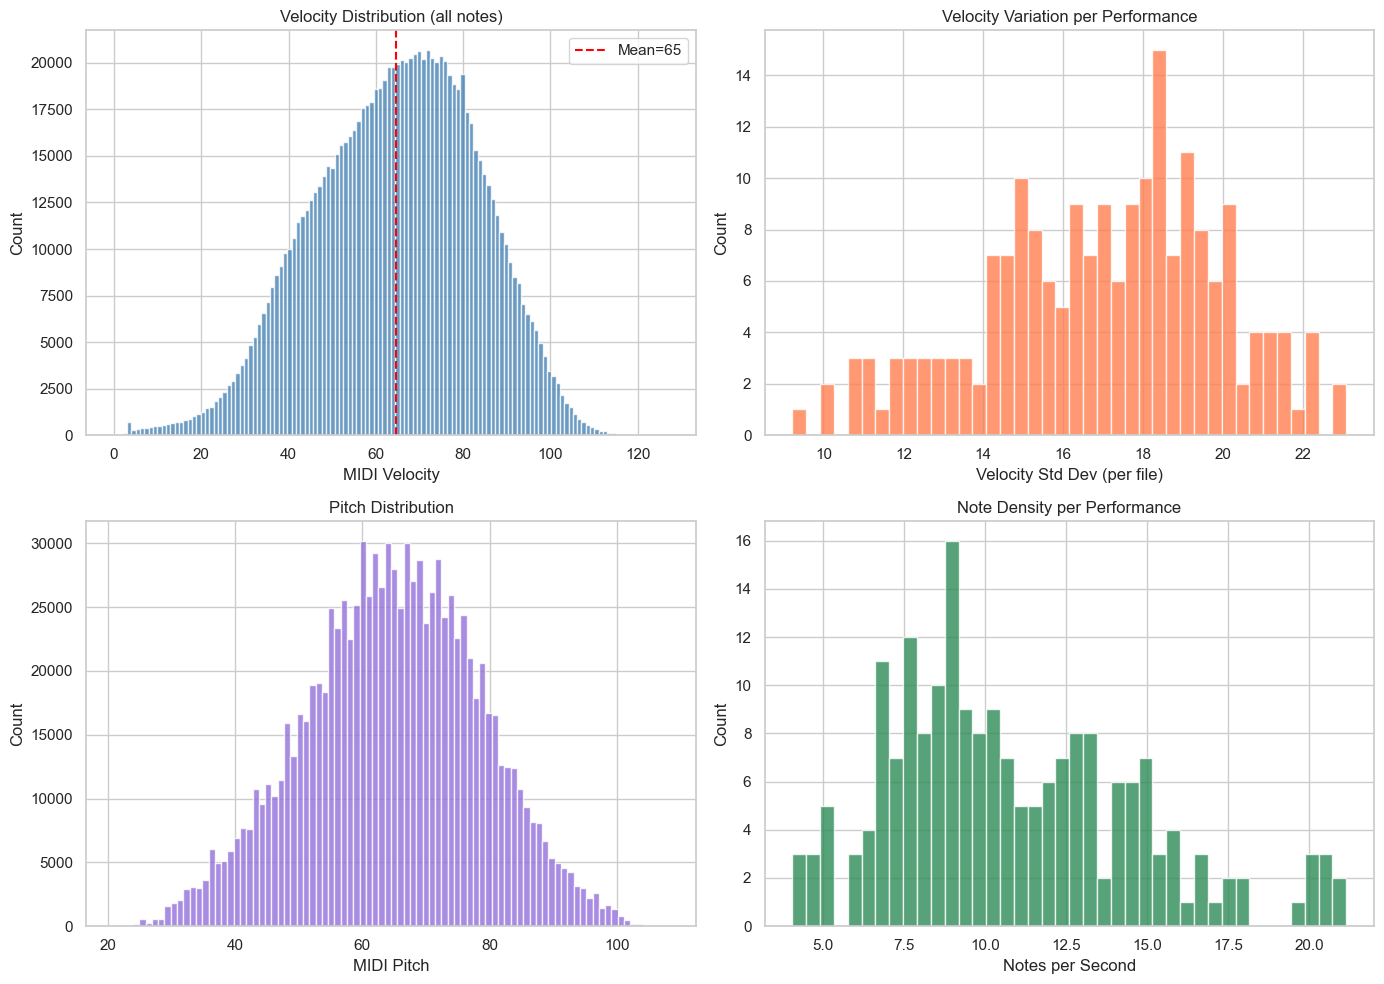


=== MAESTRO Summary ===
Velocity: mean=64.7, std=18.8, range=[1, 126]
Pitch: mean=64.7, range=[21, 108]
Note duration: mean=0.196s, median=0.086s
IOI: mean=0.1030s, median=0.0583s
Notes/sec: mean=10.8, std=3.8
Pedal usage: mean=59.8% of performance time


In [4]:
# Velocity distribution — this tells us how expressive the data is
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall velocity distribution
axes[0, 0].hist(all_velocities, bins=128, range=(0, 127), color='steelblue', alpha=0.8)
axes[0, 0].set_xlabel('MIDI Velocity')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Velocity Distribution (all notes)')
axes[0, 0].axvline(np.mean(all_velocities), color='red', linestyle='--', label=f'Mean={np.mean(all_velocities):.0f}')
axes[0, 0].legend()

# Per-file velocity std (expressiveness proxy)
axes[0, 1].hist(stats_df['std_velocity'], bins=40, color='coral', alpha=0.8)
axes[0, 1].set_xlabel('Velocity Std Dev (per file)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Velocity Variation per Performance')

# Pitch range
axes[1, 0].hist(all_pitches, bins=88, range=(21, 108), color='mediumpurple', alpha=0.8)
axes[1, 0].set_xlabel('MIDI Pitch')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Pitch Distribution')

# Note density
axes[1, 1].hist(stats_df['notes_per_sec'], bins=40, color='seagreen', alpha=0.8)
axes[1, 1].set_xlabel('Notes per Second')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Note Density per Performance')

plt.tight_layout()
plt.savefig(str(Path.home() / 'Projects' / 'apollo' / 'docs' / 'maestro_audit.png'), dpi=150)
plt.show()

print(f'\n=== MAESTRO Summary ===')
print(f'Velocity: mean={np.mean(all_velocities):.1f}, std={np.std(all_velocities):.1f}, range=[{min(all_velocities)}, {max(all_velocities)}]')
print(f'Pitch: mean={np.mean(all_pitches):.1f}, range=[{min(all_pitches)}, {max(all_pitches)}]')
print(f'Note duration: mean={np.mean(all_durations):.3f}s, median={np.median(all_durations):.3f}s')
print(f'IOI: mean={np.mean(all_ioi):.4f}s, median={np.median(all_ioi):.4f}s')
print(f'Notes/sec: mean={stats_df["notes_per_sec"].mean():.1f}, std={stats_df["notes_per_sec"].std():.1f}')
print(f'Pedal usage: mean={np.mean(pedal_usage):.1%} of performance time' if pedal_usage else 'No pedal data found')

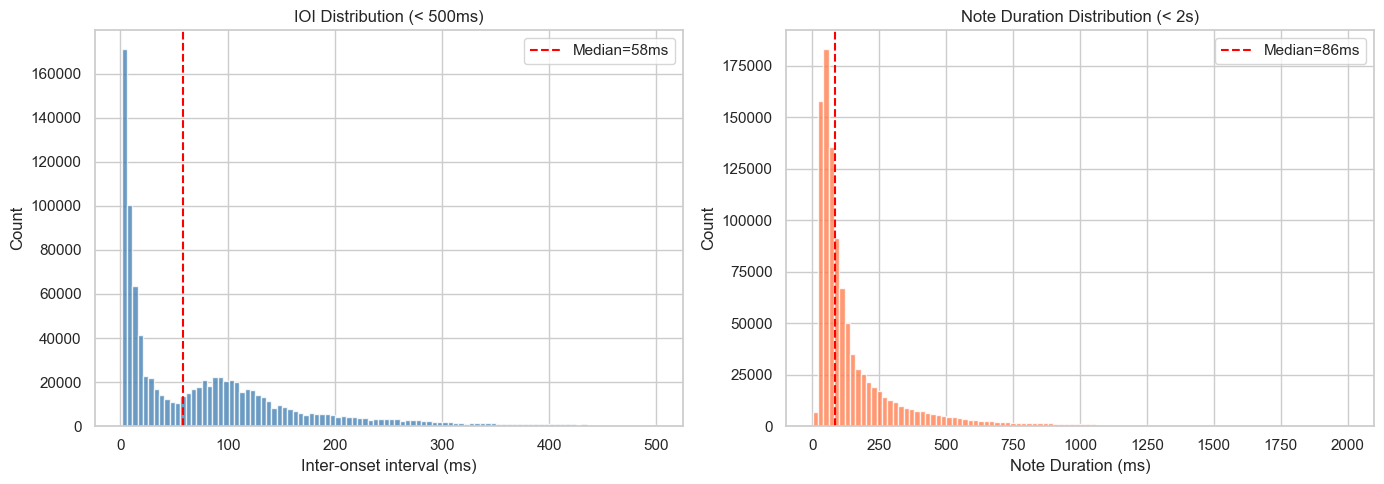


=== Timing Implications for Apollo ===
Median IOI: 58ms — this is how fast consecutive notes arrive
10th percentile IOI: 4ms — fastest typical passages
Apollo must respond within this window for real-time feel
Target inference latency: <4ms is ideal, <50ms is acceptable


In [5]:
# Timing analysis — critical for real-time system design
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IOI distribution (log scale for visibility)
ioi_ms = np.array(all_ioi) * 1000  # convert to ms
axes[0].hist(ioi_ms[ioi_ms < 500], bins=100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Inter-onset interval (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('IOI Distribution (< 500ms)')
axes[0].axvline(np.median(ioi_ms), color='red', linestyle='--', label=f'Median={np.median(ioi_ms):.0f}ms')
axes[0].legend()

# Note duration distribution
dur_ms = np.array(all_durations) * 1000
axes[1].hist(dur_ms[dur_ms < 2000], bins=100, color='coral', alpha=0.8)
axes[1].set_xlabel('Note Duration (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title('Note Duration Distribution (< 2s)')
axes[1].axvline(np.median(dur_ms), color='red', linestyle='--', label=f'Median={np.median(dur_ms):.0f}ms')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(Path.home() / 'Projects' / 'apollo' / 'docs' / 'maestro_timing.png'), dpi=150)
plt.show()

print(f'\n=== Timing Implications for Apollo ===')
print(f'Median IOI: {np.median(ioi_ms):.0f}ms — this is how fast consecutive notes arrive')
print(f'10th percentile IOI: {np.percentile(ioi_ms, 10):.0f}ms — fastest typical passages')
print(f'Apollo must respond within this window for real-time feel')
print(f'Target inference latency: <{np.percentile(ioi_ms, 10):.0f}ms is ideal, <50ms is acceptable')

In [6]:
# Save audit results for reference
audit = {
    'dataset': 'MAESTRO v3.0.0',
    'total_files': len(meta),
    'sample_size': len(stats_df),
    'total_duration_hours': float(meta['duration'].sum() / 3600),
    'velocity': {
        'mean': float(np.mean(all_velocities)),
        'std': float(np.std(all_velocities)),
        'min': int(min(all_velocities)),
        'max': int(max(all_velocities)),
    },
    'pitch': {
        'mean': float(np.mean(all_pitches)),
        'min': int(min(all_pitches)),
        'max': int(max(all_pitches)),
    },
    'timing': {
        'median_ioi_ms': float(np.median(ioi_ms)),
        'p10_ioi_ms': float(np.percentile(ioi_ms, 10)),
        'median_duration_ms': float(np.median(dur_ms)),
    },
    'density': {
        'mean_notes_per_sec': float(stats_df['notes_per_sec'].mean()),
    },
    'pedal_usage_fraction': float(np.mean(pedal_usage)) if pedal_usage else None,
}

audit_path = Path.home() / 'Projects' / 'apollo' / 'docs' / 'maestro_audit.json'
with open(audit_path, 'w') as f:
    json.dump(audit, f, indent=2)

print(f'Audit saved to {audit_path}')
print(json.dumps(audit, indent=2))

Audit saved to /Users/jeraldliu/Projects/apollo/docs/maestro_audit.json
{
  "dataset": "MAESTRO v3.0.0",
  "total_files": 1276,
  "sample_size": 200,
  "total_duration_hours": 198.653207402237,
  "velocity": {
    "mean": 64.68908171632928,
    "std": 18.821243441498954,
    "min": 1,
    "max": 126
  },
  "pitch": {
    "mean": 64.73343550277235,
    "min": 21,
    "max": 108
  },
  "timing": {
    "median_ioi_ms": 58.333333333393966,
    "p10_ioi_ms": 3.90625,
    "median_duration_ms": 86.45833333333997
  },
  "density": {
    "mean_notes_per_sec": 10.841230190249867
  },
  "pedal_usage_fraction": 0.5977040266312413
}
